# Task 4: Team Possession and Tournament Progression

## Research Question

Do teams that progressed to the knockout stage have a significantly different
average possession percentage from teams eliminated in the group stage?

## Overview

This analysis compares average possession (`Poss`) between two groups:

- **Knockout:** Teams that progressed to the Round of 32.
- **Group Eliminated:** Teams eliminated during the group stage.

The possession and match-results datasets were cleaned and matched using
standardised team names. Tournament progression was determined from match-round
information.

A proportional stratified random sample is analysed using descriptive
statistics, 95% confidence intervals, visualisations, and Welch's independent
two-sample t-test. Cohen's d is also calculated to measure effect size.

A significance level of **α = 0.05** is used.

## Descriptive Statistics

Descriptive statistics are calculated to summarise and compare possession
percentage between teams that progressed to the knockout stage and teams
eliminated during the group stage.

The statistics examined include sample size, mean, median, standard deviation,
variance, minimum, maximum, and quartiles.

In [23]:
import pandas as pd
import numpy as np

sample = pd.read_csv(
    r"C:\Users\HP\OneDrive\เอกสาร\Fifa-World-Cup-2026\notebooks\task4_team_possession_sample.csv"
)

sample.head()

,Poss,Team,Progression
0,46.3,Sweden,Knockout
1,54.1,England,Knockout
2,30.0,Paraguay,Knockout
3,65.0,Germany,Knockout
4,54.4,Canada,Knockout


In [ ]:
descriptive_stats = (
    sample.groupby("Progression")["Poss"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std_Dev="std",
        Variance="var",
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
    .round(2)
)

descriptive_stats

,Count,Mean,Median,Std_Dev,Variance,Minimum,Q1,Q3,Maximum
Progression,,,,,,,,,
Group Eliminated,12,43.02,42.70,10.10,102.00,30.7,36.97,46.03,66.3
Knockout,24,51.55,53.65,7.95,63.12,30.0,47.58,56.32,65.0


### Interpretation of Descriptive Statistics

The descriptive statistics indicate that teams progressing to the knockout
stage had a higher average possession percentage than teams eliminated during
the group stage.

Knockout teams recorded a mean possession of 51.55%, compared with 43.02% for
group-stage eliminated teams, representing an observed difference of 8.53
percentage points.

The median possession was also higher for knockout teams (53.65%) than for
eliminated teams (42.70%). The group-stage eliminated teams showed greater
variation in possession, with a standard deviation of 10.10 compared with
7.95 for knockout teams.

These descriptive results suggest a possible relationship between higher
possession and tournament progression. However, inferential statistical
testing is required to determine whether the observed difference is
statistically significant.

## Possession Distribution by Tournament Progression

A boxplot is used to compare the distribution of possession percentage between
the two progression groups and to identify differences in central tendency,
spread, and potential outliers.

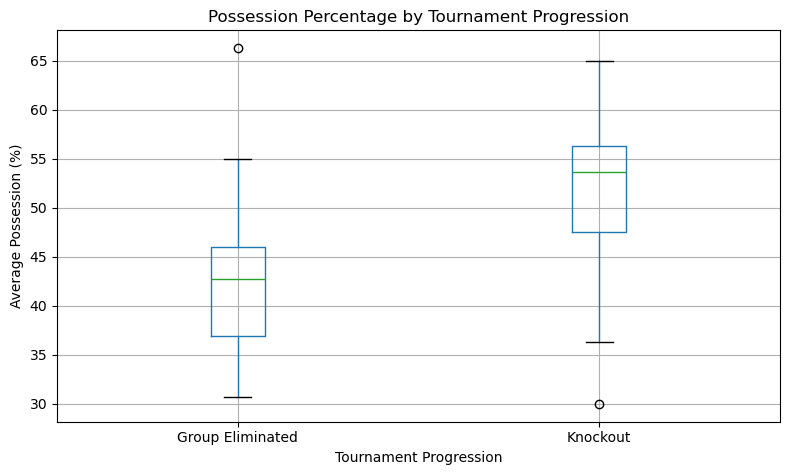

In [6]:
import matplotlib.pyplot as plt

sample.boxplot(
    column="Poss",
    by="Progression",
    figsize=(8, 5)
)

plt.title("Possession Percentage by Tournament Progression")
plt.suptitle("")
plt.xlabel("Tournament Progression")
plt.ylabel("Average Possession (%)")
plt.tight_layout()
plt.show()

### Interpretation of the Possession Distribution

The boxplot shows that teams progressing to the knockout stage generally had
higher possession percentages than teams eliminated during the group stage.
The median possession for knockout teams was 53.65%, compared with 42.70% for
group-stage eliminated teams.

Although the distributions overlap, the knockout group is generally centred
at a higher possession level. Potential outliers are also visible in both
groups, including a high-possession observation among the group-stage
eliminated teams and a low-possession observation among the knockout teams.

These observations support the pattern identified by the descriptive
statistics, but the boxplot alone cannot determine whether the difference
between the two groups is statistically significant. Further inferential
analysis is therefore required.

### Distribution of Possession Percentage

A histogram is used to examine the shape and overlap of possession percentage
distributions for knockout and group-stage eliminated teams.

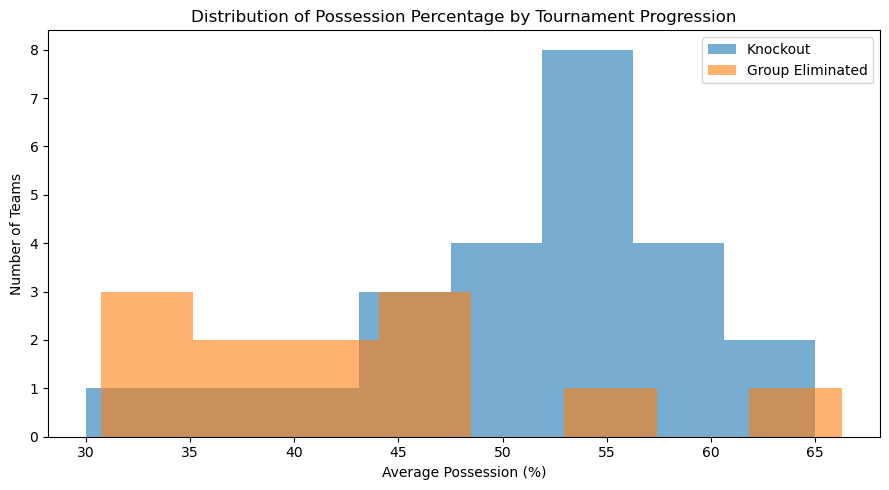

In [7]:
import matplotlib.pyplot as plt

knockout_poss = sample.loc[
    sample["Progression"] == "Knockout", "Poss"
]

eliminated_poss = sample.loc[
    sample["Progression"] == "Group Eliminated", "Poss"
]

plt.figure(figsize=(9, 5))

plt.hist(
    knockout_poss,
    bins=8,
    alpha=0.6,
    label="Knockout"
)

plt.hist(
    eliminated_poss,
    bins=8,
    alpha=0.6,
    label="Group Eliminated"
)

plt.xlabel("Average Possession (%)")
plt.ylabel("Number of Teams")
plt.title("Distribution of Possession Percentage by Tournament Progression")
plt.legend()
plt.tight_layout()
plt.show()

## 95% Confidence Intervals

A 95% confidence interval (CI) was calculated for the mean possession
percentage of each progression group. The confidence interval provides a
range of plausible values for the population mean based on the sample data.

Because the population standard deviations are unknown, the confidence
intervals are calculated using the t-distribution.

In [8]:
from scipy import stats
import numpy as np

def mean_confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    standard_error = stats.sem(data)

    t_critical = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    margin_error = t_critical * standard_error

    lower = mean - margin_error
    upper = mean + margin_error

    return mean, standard_error, lower, upper

In [9]:
for group in ["Group Eliminated", "Knockout"]:

    values = sample.loc[
        sample["Progression"] == group,
        "Poss"
    ]

    mean, se, lower, upper = mean_confidence_interval(values)

    print(f"{group}")
    print(f"Sample size = {len(values)}")
    print(f"Mean = {mean:.2f}%")
    print(f"Standard Error = {se:.2f}")
    print(f"95% CI = [{lower:.2f}%, {upper:.2f}%]")
    print()

Group Eliminated
Sample size = 12
Mean = 43.02%
Standard Error = 2.92
95% CI = [36.61%, 49.44%]

Knockout
Sample size = 24
Mean = 51.55%
Standard Error = 1.62
95% CI = [48.20%, 54.90%]



### Interpretation of 95% Confidence Intervals

The group-stage eliminated teams had a mean possession of 43.02%, with a
95% confidence interval from 36.61% to 49.44%.

The knockout teams had a higher mean possession of 51.55%, with a 95%
confidence interval from 48.20% to 54.90%.

The confidence interval for the group-stage eliminated teams is wider than
that of the knockout teams. This reflects the smaller sample size and greater
variability in possession within the eliminated group.

The results provide further evidence of a difference in average possession
between the two groups. However, the confidence intervals overlap slightly,
so statistical significance should not be determined from the confidence
intervals alone. An independent two-sample t-test will be used to formally
test whether the mean possession percentages differ significantly.

### Mean Possession with 95% Confidence Intervals

The following figure compares the mean possession percentage of the two
progression groups. Error bars represent the corresponding 95% confidence
intervals.

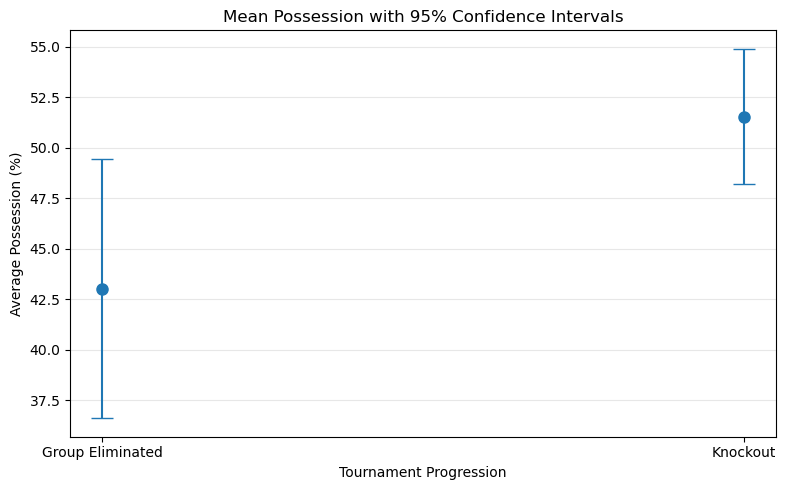

In [10]:
groups = ["Group Eliminated", "Knockout"]

means = []
lower_errors = []
upper_errors = []

for group in groups:
    values = sample.loc[
        sample["Progression"] == group,
        "Poss"
    ]

    mean, se, lower, upper = mean_confidence_interval(values)

    means.append(mean)
    lower_errors.append(mean - lower)
    upper_errors.append(upper - mean)

plt.figure(figsize=(8, 5))

plt.errorbar(
    groups,
    means,
    yerr=[lower_errors, upper_errors],
    fmt="o",
    capsize=8,
    markersize=8
)

plt.ylabel("Average Possession (%)")
plt.xlabel("Tournament Progression")
plt.title("Mean Possession with 95% Confidence Intervals")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Hypothesis Testing

An independent two-sample t-test is used to determine whether the mean
possession percentage differs significantly between teams that progressed
to the knockout stage and teams eliminated during the group stage.

The hypotheses are:

**Null hypothesis (H₀):** There is no difference in mean possession percentage
between knockout teams and group-stage eliminated teams.

H₀: μKnockout = μEliminated

**Alternative hypothesis (H₁):** There is a difference in mean possession
percentage between knockout teams and group-stage eliminated teams.

H₁: μKnockout ≠ μEliminated

A two-tailed test is used with a significance level of α = 0.05.

### Assumption Checks

Before conducting the independent two-sample t-test, the assumptions of
independence, approximate normality, and variance behaviour are considered.

In [11]:
from scipy import stats

knockout_poss = sample.loc[
    sample["Progression"] == "Knockout", "Poss"
]

eliminated_poss = sample.loc[
    sample["Progression"] == "Group Eliminated", "Poss"
]

shapiro_knockout = stats.shapiro(knockout_poss)
shapiro_eliminated = stats.shapiro(eliminated_poss)

print("Shapiro-Wilk Normality Test")
print()

print("Knockout:")
print(f"W = {shapiro_knockout.statistic:.4f}")
print(f"p-value = {shapiro_knockout.pvalue:.4f}")

print()

print("Group Eliminated:")
print(f"W = {shapiro_eliminated.statistic:.4f}")
print(f"p-value = {shapiro_eliminated.pvalue:.4f}")

Shapiro-Wilk Normality Test

Knockout:
W = 0.9398
p-value = 0.1615

Group Eliminated:
W = 0.9156
p-value = 0.2516


### Interpretation of Normality Test

The Shapiro-Wilk test was used to assess the normality of possession
percentages within each progression group.

For knockout teams, the Shapiro-Wilk test produced W = 0.9398 and
p = 0.1615. For group-stage eliminated teams, W = 0.9156 and
p = 0.2516.

Since both p-values are greater than the significance level of 0.05,
there is insufficient evidence to reject the null hypothesis of normality
for either group. Therefore, the normality assumption is considered
reasonable for the independent two-sample t-test.

The boxplot identified potential outlying observations, but these observations
represent valid teams and were retained in the analysis.

### Welch's Independent Two-Sample t-Test

Welch's independent two-sample t-test is used to compare the mean possession
percentage of knockout teams with that of group-stage eliminated teams.

Welch's version of the t-test is selected because it does not require the
assumption of equal population variances and is appropriate when group sample
sizes and variability differ.

In [12]:
t_stat, p_value = stats.ttest_ind(
    knockout_poss,
    eliminated_poss,
    equal_var=False
)

print("Welch's Independent Two-Sample t-Test")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")

Welch's Independent Two-Sample t-Test
t-statistic = 2.5553
p-value = 0.0199


In [13]:
n1 = len(knockout_poss)
n2 = len(eliminated_poss)

var1 = knockout_poss.var(ddof=1)
var2 = eliminated_poss.var(ddof=1)

welch_df = (
    (var1 / n1 + var2 / n2) ** 2
    /
    (
        (var1 / n1) ** 2 / (n1 - 1)
        + (var2 / n2) ** 2 / (n2 - 1)
    )
)

print(f"Degrees of freedom = {welch_df:.2f}")

Degrees of freedom = 18.03


### Interpretation of the t-Test

Welch's independent two-sample t-test found a statistically significant
difference in mean possession percentage between teams that progressed to
the knockout stage and teams eliminated during the group stage,
t(18.03) = 2.5553, p = 0.0199.

Since the p-value (0.0199) is less than the significance level of 0.05,
the null hypothesis is rejected.

Knockout teams recorded a higher mean possession percentage (51.55%) than
group-stage eliminated teams (43.02%), an observed difference of 8.53
percentage points.

Therefore, the sample provides evidence that average possession percentage
differs significantly between the two tournament progression groups.

## Effect Size

In addition to statistical significance, Cohen's d is calculated to measure
the magnitude of the difference in mean possession percentage between the
two progression groups.

In [14]:
# Calculate Cohen's d

n1 = len(knockout_poss)
n2 = len(eliminated_poss)

mean1 = knockout_poss.mean()
mean2 = eliminated_poss.mean()

sd1 = knockout_poss.std(ddof=1)
sd2 = eliminated_poss.std(ddof=1)

pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
    / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_sd

print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = 0.980


### Interpretation of Effect Size

Cohen's d was calculated to assess the magnitude of the difference in mean
possession percentage between the two progression groups.

The analysis produced Cohen's d = 0.980. Using conventional guidelines,
where approximately 0.2 represents a small effect, 0.5 a medium effect,
and 0.8 a large effect, this result indicates a large difference in possession
between the two groups.

Therefore, the difference in possession between knockout teams and
group-stage eliminated teams is not only statistically significant but also
substantial in magnitude within the analysed sample.

In [ ]:
### Limitation

The possession variable used in this analysis represents the available
tournament-level average possession for each team. Consequently, teams that
progressed further may have their possession calculated across more matches
than teams eliminated during the group stage.

A stronger comparison of group-stage performance would calculate possession
using only each team's group-stage matches so that possession is measured
over the same tournament phase for every team. Therefore, the findings should
be interpreted as a comparison of the available tournament-level possession
measure between progression groups.

## Conclusion

This analysis investigated whether teams that progressed to the knockout
stage of the FIFA World Cup 2026 had a significantly different average
possession percentage from teams eliminated during the group stage.

The sampled knockout teams recorded a mean possession of 51.55%, compared
with 43.02% for group-stage eliminated teams. This represents an observed
difference of 8.53 percentage points.

Welch's independent two-sample t-test identified a statistically significant
difference between the two groups, t(18.03) = 2.5553, p = 0.0199. Since the
p-value was below the 0.05 significance level, the null hypothesis was
rejected.

The effect size was also large (Cohen's d = 0.980), indicating that the
observed difference was substantial in magnitude within the analysed sample.

Overall, the results provide evidence that teams progressing to the knockout
stage had higher average possession than teams eliminated during the group
stage in this sample. However, this result should not be interpreted as
evidence that higher possession causes tournament progression. Other factors,
such as scoring efficiency, defensive performance, opposition strength, and
match context, may also influence tournament outcomes.